In [ ]:
import ee
import geemap.core as geemap

In [ ]:
ee.Authenticate()

In [ ]:
# 初始化
ee.Initialize()


# 创建Hyperion影像集合
dataset = ee.ImageCollection("EO1/HYPERION").filterDate("2016-01-01", "2017-03-01")

# 选择RGB波段
rgb = dataset.select(["B050", "B023", "B015"])

Map = geemap.Map()
Map.setCenter(162.0044, -77.3463, 9)

# 可视化参数
rgbVis = {
    "min": 1000.0,
    "max": 14000.0,
    "gamma": 2.5,
}

# 设置中心点和缩放层级
Map.setCenter(162.0044, -77.3463, 9)
Map.addLayer(rgb.median(), rgbVis, "RGB")

In [ ]:
Map

In [ ]:
roi = dataset.geometry().bounds()
roi = dataset.geometry().bounds()
print("自动计算的ROI范围:", roi.getInfo())

In [ ]:
img_list = dataset.toList(100)

In [ ]:
img_list

In [ ]:
import json
import os

from geemap import download_ee_image, ee_export_image

base_path = "/Data4/cao/ZiHanCao/exps/HyperspectralTokenizer/data/EO1-HyperION"
os.makedirs(f"{base_path}/info", exist_ok=True)
os.makedirs(f"{base_path}/images", exist_ok=True)

for i in range(img_list.size().getInfo()):
    info = img_list.get(i).getInfo()

    # 获取图像名称
    name = info["id"].split("/")[-1]

    # 保存 JSON 信息文件
    json_file = f"{base_path}/info/{name}.json"
    with open(json_file, "w") as f:
        json.dump(info, f, indent=2)

    # 导出图像
    img = ee.Image(img_list.get(i))
    img_roi = img.geometry()

    img_file = f"{base_path}/images/{name}.tif"

    try:
        # ee_export_image(img, region=img_roi, filename=img_file, scale=30)
        download_ee_image(img, region=img_roi, filename=img_file, scale=30)
        print(f"成功导出: {name}")
    except Exception as e:
        print(f"导出失败 {name}: {str(e)}")

In [ ]:
img = ee.Image(img_list.get(0))
img_roi = img.geometry().bounds()

In [13]:
import tifffile

img = tifffile.imread(
    "/Data4/cao/ZiHanCao/exps/HyperspectralTokenizer/data/EO1-HyperION/images/EO1H0010012016241110KF_SG1_01.tif"
)
img.shape, img.max(), img.min()

((198, 2131, 2820), 8832, -32768)

(-0.5, 2819.5, 2130.5, -0.5)

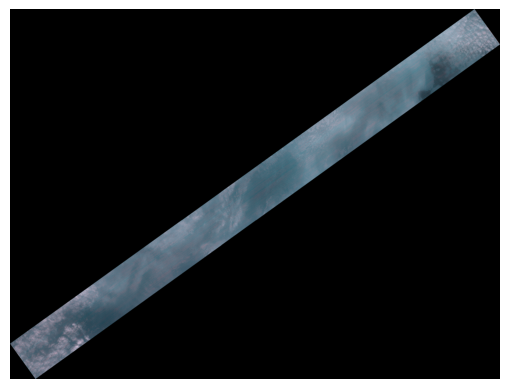

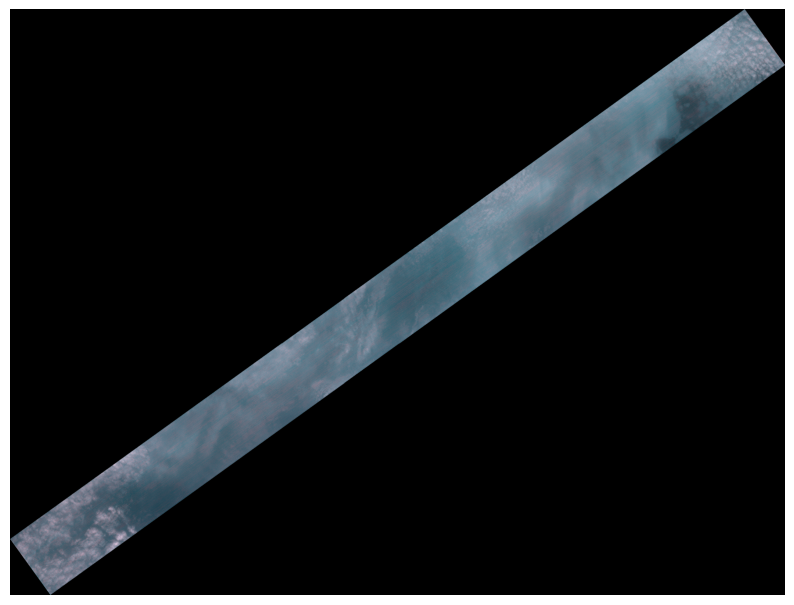

In [14]:
import numpy as np

rgb_bands = [50, 23, 15]
rgb = img[rgb_bands, :, :]

import matplotlib.pyplot as plt

rgb = np.clip(rgb, 0, None)
rgb = rgb / rgb.max()
plt.imshow(rgb.transpose(1, 2, 0))
plt.axis("off")
plt.figure(figsize=(10, 10))
rgb = np.clip(rgb, 0, None)
rgb = rgb / rgb.max()
plt.imshow(rgb.transpose(1, 2, 0))
plt.axis("off")